# ASV Detection Analysis

This notebook analyzes PAF alignment files from savont and unoise ASV detection methods to determine:
- Which reference sequences are detected as ASVs
- At what coverage/subsampling rate each ASV can be detected
- Comparison between savont and unoise methods

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
palette = sns.color_palette('muted')
import re
from collections import defaultdict
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'arial'
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

sns.set_palette('muted')
color_map = {'savont': palette[0], 'unoise': palette[1], 'unoise_min3': palette[2], 'dada2': palette[3]}
nice_names = {'savont': 'Savont', 'unoise': 'UNOISE3', 'unoise_min3': 'UNOISE3\n(min. 3 reads)', 'dada2': 'DADA2'}
#sns.set_style('whitegrid')
%matplotlib inline

## Load Coverage Data

First, load the true coverage depths for each reference sequence.

## Parse PAF Files

Parse all PAF alignment files and extract relevant information.

In [13]:
def parse_paf_line(line):
    """Parse a single PAF line and extract relevant fields."""
    fields = line.strip().split('\t')
    
    # Standard PAF fields
    paf_data = {
        'query_name': fields[0],
        'query_length': int(fields[1]),
        'query_start': int(fields[2]),
        'query_end': int(fields[3]),
        'strand': fields[4],
        'target_name': fields[5],
        'target_length': int(fields[6]),
        'target_start': int(fields[7]),
        'target_end': int(fields[8]),
        'alignment_length': int(fields[9]),
        'mapping_quality': int(fields[11]),
        'num_matches': int(fields[12].split(':')[2]),
    }
    
    # Parse optional tags
    for field in fields[12:]:
        if field.startswith('NM:i:'):
            paf_data['NM'] = int(field.split(':')[2])
        elif field.startswith('AS:i:'):
            paf_data['AS'] = int(field.split(':')[2])
        elif field.startswith('de:f:'):
            paf_data['de'] = float(field.split(':')[2])
    
    return paf_data

def parse_paf_file(paf_file):
    """Parse an entire PAF file."""
    alignments = []
    
    if not Path(paf_file).exists():
        return pd.DataFrame()
    
    with open(paf_file, 'r') as f:
        for line in f:
            if line.strip():
                alignments.append(parse_paf_line(line))
    
    return pd.DataFrame(alignments)

print("PAF parsing functions defined")

PAF parsing functions defined


In [14]:
# Get all PAF files
paf_dir = Path('results/alignments')
paf_files = sorted(paf_dir.glob('*.paf'))

print(f"Found {len(paf_files)} PAF files:")
for pf in paf_files:
    print(f"  {pf.name}")

Found 297 PAF files:
  v1v8_zmock1_frac111827.81160944818_savont.paf
  v1v8_zmock1_frac111827.81160944818_unoise.paf
  v1v8_zmock1_frac111827.81160944818_unoise_min3.paf
  v1v8_zmock1_frac1318.1911682282378_savont.paf
  v1v8_zmock1_frac1318.1911682282378_unoise.paf
  v1v8_zmock1_frac1318.1911682282378_unoise_min3.paf
  v1v8_zmock1_frac15538.424037693643_savont.paf
  v1v8_zmock1_frac15538.424037693643_unoise.paf
  v1v8_zmock1_frac15538.424037693643_unoise_min3.paf
  v1v8_zmock1_frac183162.06889755986_savont.paf
  v1v8_zmock1_frac183162.06889755986_unoise.paf
  v1v8_zmock1_frac183162.06889755986_unoise_min3.paf
  v1v8_zmock1_frac2159.0570190034573_savont.paf
  v1v8_zmock1_frac2159.0570190034573_unoise.paf
  v1v8_zmock1_frac2159.0570190034573_unoise_min3.paf
  v1v8_zmock1_frac25450.286947322187_savont.paf
  v1v8_zmock1_frac25450.286947322187_unoise.paf
  v1v8_zmock1_frac25450.286947322187_unoise_min3.paf
  v1v8_zmock1_frac300.0000000000001_savont.paf
  v1v8_zmock1_frac300.0000000000001_un

## Build Complete Dataset

Create a comprehensive dataframe with all reference sequences, subsampling rates, and methods.

In [15]:
# ── Configuration ────────────────────────────────────────────────────────────
import yaml

config_file = 'config_fl.yaml'   # ← change this to switch experiments
data         = yaml.safe_load(open(config_file))
sample_meta  = data['samples']      # {name: {platform: ont|pb, reads: path, fractions: [...]}}
samples      = list(sample_meta.keys())
ont_samples  = [s for s, m in sample_meta.items() if m['platform'] == 'ont']
pb_samples   = [s for s, m in sample_meta.items() if m['platform'] == 'pb']
primer_type  = data['primer_type']  # 'opr' or 'fl'

print("Config:", config_file)
print("Samples:", samples)
print("ONT:", ont_samples, " | PB:", pb_samples)
print("Primer type:", primer_type)
for s in samples:
    print(f"  {s}: {len(sample_meta[s]['fractions'])} fractions, "
          f"{sample_meta[s]['fractions'][0]:.0f}–{sample_meta[s]['fractions'][-1]:.0f} reads")

methods = ['savont', 'unoise', 'unoise_min3', 'dada2']

# ── Build dataset ─────────────────────────────────────────────────────────────
asv_df = pd.DataFrame()
rows   = []

for sample in samples:
    platform = sample_meta[sample]['platform']
    for fraction in sample_meta[sample]['fractions']:
        coverage_df = pd.read_csv(f'results/coverage/{sample}_frac{fraction}.tsv', sep='\t')
        coverage_df.columns = coverage_df.columns.str.strip()
        ref_names = coverage_df['rname'].tolist()
        coverage_df['ref_name'] = coverage_df['rname']

        for method in methods:
            if method == 'dada2' and platform != 'pb':
                continue

            paf_file = paf_dir / f"{sample}_frac{fraction}_{method}.paf"
            paf_df = parse_paf_file(paf_file)
            paf_df['sample']          = sample
            paf_df['fraction']        = fraction
            paf_df['method']          = method
            paf_df['sample_type']     = platform
            paf_df['Number of reads'] = fraction
            if not paf_df.empty:
                paf_df['ref_depth'] = paf_df['target_name'].map(
                    coverage_df.set_index('rname')['meandepth'])
            asv_df = pd.concat([asv_df, paf_df], ignore_index=True)

            detected_refs = set(paf_df['target_name'].unique()) if not paf_df.empty else set()
            print(detected_refs, ref_names)

            for ref_name in ref_names:
                row = {
                    'sample':      sample,
                    'fraction':    fraction,
                    'method':      method,
                    'reference':   ref_name,
                    'detected':    1 if ref_name in detected_refs else 0,
                    'sample_type': platform,
                }
                cov_info = coverage_df[coverage_df['ref_name'] == ref_name].iloc[0]
                row['true_depth']       = cov_info['meandepth']
                row['ref_length']       = cov_info['endpos'] - cov_info['startpos'] + 1
                row['expected_depth']   = row['true_depth']

                if ref_name in detected_refs:
                    aln = paf_df[paf_df['target_name'] == ref_name].sort_values('NM').iloc[0]
                    row['NM']               = aln.get('NM', np.nan)
                    row['AS']               = aln.get('AS', np.nan)
                    row['mapping_quality']  = aln['mapping_quality']
                    row['alignment_length'] = aln['alignment_length']
                    row['num_matches']      = aln['num_matches']
                    row['query_length']     = aln['query_length']
                    row['target_name']      = aln['target_name']
                    row['identity']         = (aln['num_matches'] / aln['alignment_length']
                                               if aln['alignment_length'] > 0 else 0)
                else:
                    row.update({'NM': np.nan, 'AS': np.nan, 'mapping_quality': np.nan,
                                'alignment_length': np.nan, 'num_matches': np.nan,
                                'query_length': np.nan, 'target_name': np.nan,
                                'identity': np.nan})
                rows.append(row)

df = pd.DataFrame(rows)
print(f"Created dataframe with {len(df)} rows")
print(f"Total detections: {df['detected'].sum()}")
print(f"Detection rate: {df['detected'].mean():.2%}")

Config: config_fl.yaml
Samples: ['v1v8_zmock1', 'ziels_pb_zymo']
ONT: ['v1v8_zmock1']  | PB: ['ziels_pb_zymo']
Primer type: fl
  v1v8_zmock1: 15 fractions, 300–300000 reads
  ziels_pb_zymo: 15 fractions, 50–50000 reads
{'Bacillus_4_5;size=3', 'Enterococcus_4;size=4'} ['Salmonella_5;size=5', 'Enterococcus_4;size=4', 'Staphylococcus_4;size=4', 'Bacillus_4_5;size=3', 'Bacillus_7;size=2', 'Escherichia_5;size=2', 'Listeria_2_5;size=2', 'Listeria_6;size=2', 'Bacillus_1;size=1', 'Bacillus_3;size=1', 'Bacillus_8;size=1', 'Bacillus_9;size=1', 'Escherichia_1;size=1', 'Escherichia_2;size=1', 'Escherichia_6;size=1', 'Escherichia_7;size=1', 'Lactobacillus_1;size=1', 'Lactobacillus_2;size=1', 'Lactobacillus_3;size=1', 'Lactobacillus_4;size=1', 'Lactobacillus_5;size=1', 'Listeria_1;size=1', 'Pseudomonas_1_2_3_4;size=1', 'Salmonella_7;size=1', 'Staphylococcus_2;size=1', 'Staphylococcus_3;size=1', 'Escherichia_4;size=1']
set() ['Salmonella_5;size=5', 'Enterococcus_4;size=4', 'Staphylococcus_4;size=4', 

## Summary Statistics

In [16]:
# Detection rate by method and fraction
df_nm0 = df[df['NM'] == 0]

detection_summary = df.groupby(['sample', 'method', 'fraction']).agg({
    'detected': ['count']
}).round(3)

print(detection_summary)

nm_upper_map = {'pb': 10, 'ont': 10_000_000}
false_positives = asv_df[
    (asv_df['NM'] > 0) &
    (asv_df['NM'] < asv_df['sample_type'].map(nm_upper_map))
]
false_positives = false_positives.groupby(['sample', 'method', 'fraction']).size().reset_index(name='false_positives')
print(false_positives.columns)

detection_summary.columns = ['total_refs']
detection_summary = detection_summary.reset_index()
detection_summary = pd.merge(detection_summary, false_positives,
                             on=['sample', 'method', 'fraction'], how='left')
num_detect = df_nm0.groupby(['sample', 'method', 'fraction'])['detected'].sum().reset_index()
detection_summary['num_detected'] = pd.merge(
    detection_summary, num_detect, on=['sample', 'method', 'fraction'], how='left')['detected']
detection_summary['detection_rate'] = (detection_summary['num_detected']
                                       / detection_summary['total_refs'])

print(detection_summary)
for sample in samples:
    for method in methods:
        total = detection_summary[
            (detection_summary['sample'] == sample) &
            (detection_summary['method'] == method)]['num_detected'].sum()
        print(f"Total true ASVs for {sample} with {method}: {total}")

                                       detected
                                          count
sample        method      fraction             
v1v8_zmock1   savont      300.000000         27
                          491.368112         27
                          804.808739         27
                          1318.191168        27
                          2159.057019        27
...                                         ...
ziels_pb_zymo unoise_min3 6947.477500        27
                          11379.229600       27
                          18637.968600       27
                          30527.011500       27
                          50000.000000       27

[105 rows x 1 columns]
Index(['sample', 'method', 'fraction', 'false_positives'], dtype='object')
            sample       method      fraction  total_refs  false_positives  \
0      v1v8_zmock1       savont    300.000000          27              NaN   
1      v1v8_zmock1       savont    491.368112          27              Na

In [17]:
# Detection by reference and method
ref_detection = df.pivot_table(
    index='reference',
    columns=['sample', 'method', 'fraction'],
    values='detected',
    aggfunc='first'
)

print("\nDetection Matrix (1=detected, 0=not detected):")
display(ref_detection)


Detection Matrix (1=detected, 0=not detected):


sample                      v1v8_zmock1                            \
method                           savont                             
fraction                   300.000000   491.368112   804.808739     
reference                                                           
Bacillus_1;size=1                     0            0            0   
Bacillus_3;size=1                     0            0            0   
Bacillus_4_5;size=3                   1            1            1   
Bacillus_7;size=2                     0            0            0   
Bacillus_8;size=1                     0            0            1   
Bacillus_9;size=1                     0            0            0   
Enterococcus_4;size=4                 1            1            1   
Escherichia_1;size=1                  0            0            0   
Escherichia_2;size=1                  0            0            0   
Escherichia_4;size=1                  0            0            0   
Escherichia_5;size=2                  0            0            0   
Escherichia_6;size=1                  0            0            0   
Escherichia_7;size=1                  0            0            0   
Lactobacillus_1;size=1                0            0            0   
Lactobacillus_2;size=1                0            0            0   
Lactobacillus_3;size=1                0            1            1   
Lactobacillus_4;size=1                0            0            0   
Lactobacillus_5;size=1                0            0            0   
Listeria_1;size=1                     0            0            0   
Listeria_2_5;size=2                   0            0            0   
Listeria_6;size=2                     0            0            0   
Pseudomonas_1_2_3_4;size=1            0            0            0   
Salmonella_5;size=5                   0            0            1   
Salmonella_7;size=1                   0            0            0   
Staphylococcus_2;size=1               0            0            0   
Staphylococcus_3;size=1               0            0            0   
Staphylococcus_4;size=4               0            1            1   

sample                                                             \
method                                                              
fraction                   1318.191168  2159.057019  3536.305904    
reference                                                           
Bacillus_1;size=1                     0            0            0   
Bacillus_3;size=1                     0            0            0   
Bacillus_4_5;size=3                   1            1            1   
Bacillus_7;size=2                     1            1            1   
Bacillus_8;size=1                     1            1            1   
Bacillus_9;size=1                     0            0            0   
Enterococcus_4;size=4                 1            1            1   
Escherichia_1;size=1                  0            1            1   
Escherichia_2;size=1                  0            0            1   
Escherichia_4;size=1                  0            0            1   
Escherichia_5;size=2                  0            0            1   
Escherichia_6;size=1                  0            0            1   
Escherichia_7;size=1                  0            0            1   
Lactobacillus_1;size=1                0            0            0   
Lactobacillus_2;size=1                1            1            1   
Lactobacillus_3;size=1                1            1            1   
Lactobacillus_4;size=1                1            1            1   
Lactobacillus_5;size=1                0            0            1   
Listeria_1;size=1                     0            0            1   
Listeria_2_5;size=2                   1            1            1   
Listeria_6;size=2                     0            0            1   
Pseudomonas_1_2_3_4;size=1            1            1            1   
Salmonella_5;size=5                   0            1            1 

## Visualization: Detection Probability vs True Depth

Bin data points in log10 space to create detection probability curves.

        sample  fraction  method                reference  detected  \
0  v1v8_zmock1     300.0  savont      Salmonella_5;size=5         0   
1  v1v8_zmock1     300.0  savont    Enterococcus_4;size=4         1   
2  v1v8_zmock1     300.0  savont  Staphylococcus_4;size=4         0   
3  v1v8_zmock1     300.0  savont      Bacillus_4_5;size=3         1   
4  v1v8_zmock1     300.0  savont        Bacillus_7;size=2         0   

  sample_type  true_depth  ref_length  expected_depth   NM      AS  \
0         ont    15.55980        1363        15.55980  NaN     NaN   
1         ont    33.89860        1381        33.89860  0.0  2760.0   
2         ont    39.83670        1372        39.83670  NaN     NaN   
3         ont    14.97450        1370        14.97450  0.0  2738.0   
4         ont     9.95912        1370         9.95912  NaN     NaN   

   mapping_quality  alignment_length  num_matches  query_length  \
0              NaN               NaN          NaN           NaN   
1             60.0

/tmp/ipykernel_2082099/344249471.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method_df['detected'] = method_df['detected'] * (method_df['NM'] == 0)
/tmp/ipykernel_2082099/344249471.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method_df['detected'] = method_df['detected'] * (method_df['NM'] == 0)
/tmp/ipykernel_2082099/344249471.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

Method: savont, Sample: v1v8_zmock1, NM >= 1 - Detection rate: 0.00%
Method: savont, Sample: ziels_pb_zymo, NM >= 1 - Detection rate: 3.92%


/tmp/ipykernel_2082099/344249471.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method_df['detected'] = (method_df['NM'] >= nm)
/tmp/ipykernel_2082099/344249471.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method_df['detected'] = (method_df['NM'] >= nm)
/tmp/ipykernel_2082099/344249471.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

Method: unoise, Sample: v1v8_zmock1, NM >= 1 - Detection rate: 0.66%
Method: unoise, Sample: ziels_pb_zymo, NM >= 1 - Detection rate: 1.57%
Method: unoise_min3, Sample: v1v8_zmock1, NM >= 1 - Detection rate: 4.57%


/tmp/ipykernel_2082099/344249471.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method_df['detected'] = (method_df['NM'] >= nm)
/tmp/ipykernel_2082099/344249471.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method_df['detected'] = (method_df['NM'] >= nm)
/tmp/ipykernel_2082099/344249471.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

Method: unoise_min3, Sample: ziels_pb_zymo, NM >= 1 - Detection rate: 4.11%
Method: dada2, Sample: v1v8_zmock1, NM >= 1 - Detection rate: nan%
Method: dada2, Sample: ziels_pb_zymo, NM >= 1 - Detection rate: 4.42%


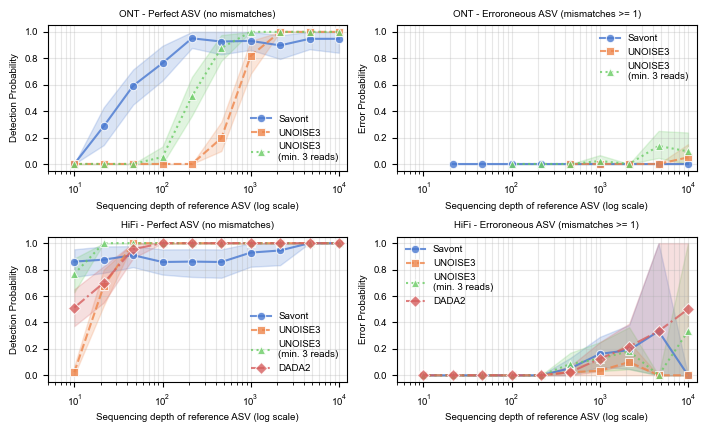


Detection Summary by Bin:


In [18]:
# Create detection probability curves binned in log10 space
#markers_dict = {'savont': 'o', 'unoise': 's', 'unoise_min3': '^'}
markers_dict = {'v1v8_zmock1': 'o', 'v1v8_zmock1_pb': 's', 'FBB38036_bam_pass.1': 'o'}
markers_dict_method = {'savont': 'o', 'unoise': 's', 'unoise_min3': '^', 'dada2': 'D'}
style_dict = {'savont': 'solid', 'unoise': 'dashed', 'unoise_min3': 'dotted', 'dada2': 'dashdot'}
# Calculate log10 of true_depth
palette = sns.color_palette('muted', n_colors=len(methods))
print(df.head(), f"Dataframe loaded with {len(df)} rows and columns: {df.columns.tolist()}")
asv_df['log10_ref_depth'] = np.log10(asv_df['ref_depth'] + 1e-6)  # Add small constant to avoid log10(0)
df['log10_true_depth'] = np.log10(df['true_depth'] + 1e-6)  # Add small constant to avoid log10(0)
# Define bins in log10 space with bin width of 1.0
bin_width = 1

# Assign each row to a bin based on its log10_true_depth
def assign_bin(log_depth):
    """Assign a data point to a bin with midpoint spacing of 0.5 in log10 space"""
    # Find the nearest bin midpoint
    bin_mid = np.round(log_depth * 3) / 3  # Round to nearest 0.5
    return bin_mid

asv_df['bin_mid_log10'] = asv_df['log10_ref_depth'].apply(assign_bin)
asv_df['bin_mid_depth'] = 10 ** asv_df['bin_mid_log10']

df['bin_mid_log10'] = df['log10_true_depth'].apply(assign_bin)
df['bin_mid_depth'] = 10 ** df['bin_mid_log10']
df['sample_method'] = df['sample'] + '_' + df['method']
# Plot detection probability vs true depth with error bars
fig, axes = plt.subplots(2, 2, figsize=(18/2.54, 11/2.54))
for nm in [0, 1]:
    for method in methods:
        for sample in samples:
            if nm == 0:
                method_df = df[(df['method'] == method) & (df['sample'] == sample)]  # Replace 100 with your desired threshold
                method_df['detected'] = method_df['detected'] * (method_df['NM'] == 0)
            else:
                method_df = asv_df[(asv_df['method'] == method) & (asv_df['sample'] == sample)]  # Replace 100 with your desired threshold
                method_df['detected'] = (method_df['NM'] >= nm)
                print(f"Method: {method}, Sample: {sample}, NM >= {nm} - Detection rate: {method_df['detected'].mean():.2%}")

            method_df = method_df[method_df['bin_mid_depth'] > 5]  # Filter out zero depth bins
            method_df = method_df[method_df['bin_mid_depth'] < 10005]  # Filter out zero depth bins
            # Use seaborn lineplot for automatic mean and confidence interval calculation
            is_pb = sample_meta[sample]['platform'] == 'pb'
            if is_pb:
                ax = axes[1][nm]
            else:
                ax = axes[0][nm]
                if method == 'dada2':
                    continue
            sns.lineplot(data=method_df, x='bin_mid_depth', y='detected', 
                        marker=markers_dict_method[method], linestyle=style_dict[method], color = color_map[method], ax=ax, alpha=0.8,
                        label = nice_names[method])



    #plt.legend(frameon=False)
    for sample_type, row in zip(['ONT', 'HiFi'], axes):
        for i,ax in enumerate(row):
            ax.set_xscale('log')
            if i == 0:
                ax.set_title(f'{sample_type} - Perfect ASV (no mismatches)', fontsize=7)
                ax.set_ylabel('Detection Probability',)
                ax.set_xlabel('Sequencing depth of reference ASV (log scale)',  )
            else:
                ax.set_title(f'{sample_type} - Erroroneous ASV (mismatches >= {nm})', fontsize=7)
                ax.set_ylabel('Error Probability',)
                ax.set_xlabel('Sequencing depth of reference ASV (log scale)',  )

        #if nm == 0:
            #ax.set_title(f'ASV Detection Probability (no mismatches) vs Depth')
       # else:
            #ax.set_title(f'ASV Detection Probability (mismatches >= {nm}) vs Depth')
            ax.legend(  frameon=False)
            ax.grid(True, alpha=0.3, which='both')
            ax.set_ylim(-0.05, 1.05)
            ax.set_xlim(5, 12500)

    #axes[0].set_title('ASV - ONT (D6300 Mock Community)')
    #axes[1].set_title('ASV - HiFi (D6300 Mock Community)')
    #ax.set_xlim(5, 10000)

    # Add horizontal line at 0.5
    #ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(f'figures/detection_probability_vs_depth_nm_{nm}.svg', dpi=300, bbox_inches='tight')
plt.show()

# Show summary statistics by bin
print("\nDetection Summary by Bin:")
bin_summary = df.groupby(['sample', 'method', 'bin_mid_log10', 'bin_mid_depth']).agg({
    'detected': ['mean', 'std', 'count']
}).round(3)
bin_summary.columns = ['detection_prob', 'std_dev', 'n_points']
bin_summary = bin_summary.reset_index()
#pd.set_option('display.max_rows', None)
#display(bin_summary)

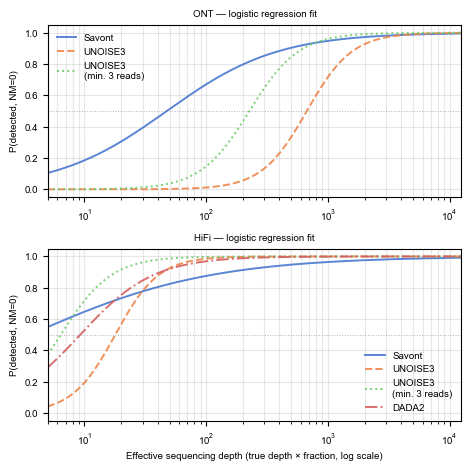

In [19]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# ── 1) Logistic regression: P(detected, NM=0) ~ log10(eff_depth) ────────────
fig, axes = plt.subplots(2, 1, figsize=(12/2.54, 12/2.54), sharex=False)
ax_ont, ax_pb = axes

x_grid = np.linspace(np.log10(5), np.log10(12500), 300).reshape(-1, 1)

for method in methods:
    for sample in samples:
        if sample_meta[sample]['platform'] == 'pb':
            ax = ax_pb
        else:
            ax = ax_ont
            if method == 'dada2':
                continue

        sub = df[(df['method'] == method) & (df['sample'] == sample)].copy()
        sub['eff_depth'] = sub['true_depth'] 
        sub['detected_perfect'] = (sub['detected'] & (sub['NM'] == 0)).astype(float)
        sub = sub[sub['eff_depth'] > 0].dropna(subset=['eff_depth', 'detected_perfect'])
        if len(sub) < 10 or sub['detected_perfect'].nunique() < 2:
            continue

        X = np.log10(sub['eff_depth'].values).reshape(-1, 1)
        y = sub['detected_perfect'].values

        clf = LogisticRegression(max_iter=1000)
        clf.fit(X, y)
        y_pred = clf.predict_proba(x_grid)[:, 1]

        ax.plot(
            10 ** x_grid.ravel(), y_pred,
            color=color_map[method],
            linestyle=style_dict[method],
            linewidth=1.4,
            label=nice_names[method],
            alpha=0.9,
        )

for ax, title in zip(axes, ['ONT', 'HiFi']):
    ax.set_xscale('log')
    ax.set_xlim(5, 12500)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('P(detected, NM=0)')
    ax.set_title(f'{title} — logistic regression fit', fontsize=7)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3, which='both')
    ax.axhline(0.5, color='grey', linewidth=0.7, linestyle=':', alpha=0.6)

ax_pb.set_xlabel('Effective sequencing depth (true depth × fraction, log scale)')
plt.tight_layout()
plt.savefig(f'figures/{samples[0]}_detection_probability_logistic.svg', dpi=300, bbox_inches='tight')
plt.show()


Method: savont, Sample: v1v8_zmock1 - k-NN smoothed detection probability crosses 50% at depth 39
Method: savont, Sample: v1v8_zmock1 - k-NN smoothed detection probability crosses 75% at depth 81
Method: savont, Sample: v1v8_zmock1 - k-NN smoothed detection probability crosses 90% at depth 135
Method: savont, Sample: ziels_pb_zymo - k-NN smoothed detection probability crosses 50% at depth 5
Method: savont, Sample: ziels_pb_zymo - k-NN smoothed detection probability crosses 75% at depth 7
Method: savont, Sample: ziels_pb_zymo - k-NN smoothed detection probability crosses 90% at depth 15
Method: unoise, Sample: v1v8_zmock1 - k-NN smoothed detection probability crosses 50% at depth 679
Method: unoise, Sample: v1v8_zmock1 - k-NN smoothed detection probability crosses 75% at depth 887
Method: unoise, Sample: v1v8_zmock1 - k-NN smoothed detection probability crosses 90% at depth 1127
Method: unoise, Sample: ziels_pb_zymo - k-NN smoothed detection probability crosses 50% at depth 19
Method: u

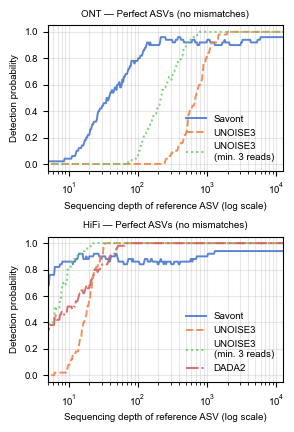

In [20]:
# ── 2) k-nearest-neighbours moving window smoothing ──────────────────────────
# For each point sorted by log10(eff_depth), average detected_perfect over
# the K nearest neighbours in log-depth space.

from sklearn.neighbors import KNeighborsRegressor

K = 50   # neighbourhood size — increase to smooth more, decrease for more local

fig, axes = plt.subplots(2, 1, figsize=(7.5/2.54, 11/2.54), sharex=False)
ax_ont, ax_pb = axes

max_x = df['log10_true_depth'].max()

x_grid = np.linspace(np.log10(2), max_x, 400).reshape(-1, 1)

for method in methods:
    for sample in samples:
        if sample_meta[sample]['platform'] == 'pb':
            ax = ax_pb
        else:
            ax = ax_ont
            if method == 'dada2':
                continue

        sub = df[(df['method'] == method) & (df['sample'] == sample)].copy()
        sub['eff_depth'] = sub['true_depth'] 
        sub['detected_perfect'] = (sub['detected'] & (sub['NM'] == 0)).astype(float)
        sub = sub[sub['eff_depth'] > 0].dropna(subset=['eff_depth', 'detected_perfect'])
        if len(sub) < K:
            continue

        X = np.log10(sub['eff_depth'].values).reshape(-1, 1)
        y = sub['detected_perfect'].values

        knn = KNeighborsRegressor(n_neighbors=K, weights='uniform', metric='euclidean')
        knn.fit(X, y)
        y_pred = np.clip(knn.predict(x_grid), 0, 1)

        ax.plot(
            10 ** x_grid.ravel(), y_pred,
            color=color_map[method],
            linestyle=style_dict[method],
            linewidth=1.4,
            label=nice_names[method],
            alpha=0.9,
        )

        #print(f"Method: {method}, Sample: {sample} - k-NN smoothed detection probability at depth 100: {knn.predict([[np.log10(100)]])[0]:.2%}")

        # print k-NN smoothed detection probability at specific depths
        # crossing points at 50%, 75% and 90% detection probability
        hit_50 = False
        hit_75 = False
        hit_90 = False
        for depth in np.linspace(1, 3000, 1500):

            pred_prob = knn.predict([[np.log10(depth)]])[0]

            if not hit_50 and pred_prob >= 0.5:
                print(f"Method: {method}, Sample: {sample} - k-NN smoothed detection probability crosses 50% at depth {depth:.0f}")
                hit_50 = True
            if not hit_75 and pred_prob >= 0.75:
                print(f"Method: {method}, Sample: {sample} - k-NN smoothed detection probability crosses 75% at depth {depth:.0f}")
                hit_75 = True
            if not hit_90 and pred_prob >= 0.90:
                print(f"Method: {method}, Sample: {sample} - k-NN smoothed detection probability crosses 90% at depth {depth:.0f}")
                hit_90 = True
       
           # print(f"Method: {method}, Sample: {sample} - k-NN smoothed detection probability at depth {depth:.0f}: {pred_prob:.2%}")
for ax, title in zip(axes, ['ONT', 'HiFi']):
    ax.set_xscale('log')

    ax.set_xlim(5, 3000 if primer_type == 'opr' else 12500)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Detection probability')
    ax.set_title(f'{title} — Perfect ASVs (no mismatches)', fontsize=7)
    ax.set_xlabel('Sequencing depth of reference ASV (log scale)')
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3, which='both')
    #ax.axhline(0.5, color='grey', linewidth=0.7, linestyle=':', alpha=0.6)
print("Total data points used for k-NN smoothing:", len(sub))
#ax_pb.set_xlabel('Sequencing depth of ASV (log scale)')
plt.tight_layout()
plt.savefig(f'figures/{samples[0]}_detection_probability_knn_K{K}.svg', dpi=300, bbox_inches='tight')
plt.show()


## Species-Level Analysis

Aggregate ASVs by species and analyze detection probability at the species level.

In [21]:
# Extract species from reference name (first token before '_')
#df['species'] = df['reference'].str.split('_').str[0]
#
## Create species-level dataframe
#species_rows = []
#
#for sample in samples:
#    
#    # Calculate species-level coverage from the coverage data
#    coverage_df = coverage_df_map[sample]
#    species_coverage = coverage_df.copy()
#    species_coverage['species'] = species_coverage['rname'].str.split('_').str[0]
#
#    # Sum depths by species
#    species_depth_map = species_coverage.groupby('species')['meandepth'].sum().to_dict()
#
#    for fraction in fractions:
#        for method in methods:
#            for species in species_depth_map.keys():
#                # Get all ASVs for this species
#                species_asvs = df[(df['sample'] == sample) & 
#                                  (df['fraction'] == fraction) & 
#                                  (df['method'] == method) & 
#                                  (df['species'] == species)]
#                some_perfect_hit = (species_asvs['NM'] == 0).any()
#                
#                # Species is detected if at least one ASV is detected
#                species_detected = 1 if species_asvs['detected'].sum() > 0 and some_perfect_hit else 0
#                
#                # Get species depth
#                species_true_depth = species_depth_map[species]
#                
#                species_rows.append({
#                    'sample': sample,
#                    'fraction': fraction,
#                    'method': method,
#                    'species': species,
#                    'detected': species_detected,
#                    'true_depth': species_true_depth,
#                    'expected_depth': species_true_depth,
#                    'num_asvs_total': len(species_asvs),
#                    'num_asvs_detected': species_asvs['detected'].sum()
#                })
#
#species_df = pd.DataFrame(species_rows)
#
#print(f"Created species dataframe with {len(species_df)} rows")
#print(f"Number of unique species: {species_df['species'].nunique()}")
#print(f"Species detection rate: {species_df['detected'].mean():.2%}")
#species_df.to_csv('species_detection_summary.csv', index=False)

In [22]:
# Create species-level detection probability plot

# Calculate log10 of species true_depth
#species_df['log10_true_depth'] = np.log10(species_df['true_depth']  + 1e-6)
#
## Assign each row to a bin
#species_df['bin_mid_log10'] = species_df['log10_true_depth'].apply(assign_bin)
#species_df['bin_mid_depth'] = 10 ** species_df['bin_mid_log10']
#
## Plot species detection probability vs species depth
#fig, axes = plt.subplots(1,2, figsize=(18/2.54, 7/2.54))
#
#for method in methods:
#    for sample in samples:
#        method_df = species_df[(species_df['method'] == method) & (species_df['sample'] == sample)]
#        if 'pb' not in sample and method == 'dada2':
#            continue
#        if 'pb' in sample:
#            ax = axes[1]
#        else:
#            ax = axes[0]
#        
#        # Use seaborn lineplot for automatic mean and confidence interval calculation
#        sns.lineplot(data=method_df, x='bin_mid_depth', y='detected', 
#                    marker=markers_dict[sample], color = color_map[method], ax=ax, alpha=0.8,
#                    label=method)
#for ax in axes:
#    ax.set_xscale('log')
#    ax.set_xlabel('Sum of ASV depth for species (log scale)')
#    ax.set_ylabel('Detection Probability')
#    ax.legend(loc='lower right', frameon=False)
#    ax.grid(True, alpha=0.3, which='both')
#    ax.set_ylim(-0.05, 1.05)
#    ax.set_xlim(5, 12500)
#    # Add horizontal line at 0.5
#    #ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
#
#axes[0].set_title('Species - ONT (D6300 Mock Community)')
#axes[1].set_title('Species - HiFi (D6300 Mock Community)')
#
#plt.tight_layout()
#plt.savefig('figures/species_detection_probability_vs_depth.png', dpi=300, bbox_inches='tight')
#plt.show()
#
## Show summary statistics by bin
#print("\nSpecies Detection Summary by Bin:")
#species_bin_summary = species_df.groupby(['sample', 'method', 'bin_mid_log10', 'bin_mid_depth']).agg({
#    'detected': ['mean', 'std', 'count']
#}).round(3)
#
#species_bin_summary.columns = ['detection_prob', 'std_dev', 'n_points']
#species_bin_summary = species_bin_summary.reset_index()
#display(species_bin_summary)

## Visualization: Detection Rate by Fraction

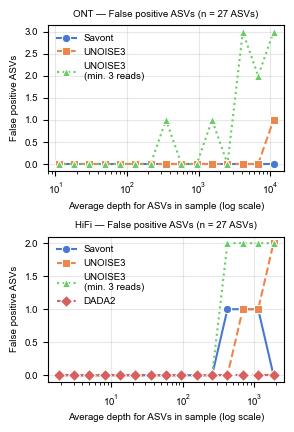

savont, v1v8_zmock1 — mean F1 <100x depth: 40.29%
savont, ziels_pb_zymo — mean F1 <100x depth: 74.83%
unoise, v1v8_zmock1 — mean F1 <100x depth: 0.00%
unoise, ziels_pb_zymo — mean F1 <100x depth: 43.73%
unoise_min3, v1v8_zmock1 — mean F1 <100x depth: 5.62%
unoise_min3, ziels_pb_zymo — mean F1 <100x depth: 65.07%
dada2, v1v8_zmock1 — mean F1 <100x depth: nan%
dada2, ziels_pb_zymo — mean F1 <100x depth: 62.35%


In [23]:
# Detection rate by fraction
f1 = False
fraction = False
fig, axes = plt.subplots(2, 1, figsize=(7.5/2.54, 11/2.54), sharex=False)
detection_summary.replace({np.nan: 0}, inplace=True)

detection_summary['Sensitivity'] = (detection_summary['num_detected']
                                    / detection_summary['total_refs'])
detection_summary['Precision'] = 1 - (
    detection_summary['false_positives']
    / (detection_summary['false_positives'] + detection_summary['num_detected']))
detection_summary['F1'] = (
    2 * (detection_summary['Precision'] * detection_summary['Sensitivity'])
    / (detection_summary['Precision'] + detection_summary['Sensitivity'] + 1e-6)
).fillna(0)

if not fraction:
    detection_summary['num_reads'] = detection_summary['fraction']
else:
    detection_summary['num_reads'] = detection_summary['fraction']  # fractions are already read counts

detection_summary['num_reads_avg'] = detection_summary['num_reads'] / detection_summary['total_refs']
methods_plot = detection_summary['method'].unique()

for method in methods_plot:
    for sample in samples:
        method_summary = detection_summary[
            (detection_summary['method'] == method) &
            (detection_summary['sample'] == sample)]
        is_pb = sample_meta[sample]['platform'] == 'pb'
        if is_pb:
            ax = axes[1]
        else:
            if method == 'dada2':
                continue
            ax = axes[0]
        y_col = 'F1' if f1 else 'false_positives'
        sns.lineplot(data=method_summary, x='num_reads_avg', y=y_col,
                     label=nice_names[method], color=color_map[method],
                     marker=markers_dict_method[method],
                     linestyle=style_dict[method], ax=ax)

num_asvs = df['reference'].nunique()
#xlim = (5, 3000) if primer_type == 'opr' else (5, 20000)
for ax in axes:
    ax.set_xlabel('Average depth for ASVs in sample (log scale)')
    if f1:
        ax.set_ylabel('F1 Score')
        ax.set_title(
            f'{"ONT" if ax == axes[0] else "HiFi"} — F1 Score (n = {num_asvs} ASVs)',
            fontsize=7)
    else:
        ax.set_ylabel('False positive ASVs')
        ax.set_title(
            f'{"ONT" if ax == axes[0] else "HiFi"} — False positive ASVs (n = {num_asvs} ASVs)',
            fontsize=7)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)
    #ax.set_xlim(*xlim)
    ax.set_xscale('log')

plt.tight_layout()
suffix = 'f1_score' if f1 else 'false_positive_asvs'
plt.savefig(f'figures/{samples[0]}_{suffix}_by_fraction.svg', dpi=300, bbox_inches='tight')
plt.show()

for method in methods_plot:
    for sample in samples:
        method_summary = detection_summary[
            (detection_summary['method'] == method) &
            (detection_summary['sample'] == sample)]
        low_depth = method_summary[method_summary['num_reads_avg'] < 100]
        print(f"{method}, {sample} — mean F1 <100x depth: {low_depth['F1'].mean():.2%}")

## Minimum Detection Threshold Analysis

For each reference, find the minimum coverage at which it was detected.

In [24]:
# Find minimum detection threshold for each reference and method
min_detection = []

for method in methods:
    for ref in ref_names:
        ref_data = df[(df['reference'] == ref) & (df['method'] == method) & (df['detected'] == 1)]
        
        if len(ref_data) > 0:
            min_depth = ref_data['expected_depth'].min()
            min_fraction = ref_data['fraction'].min()
            max_fraction_detected = ref_data['fraction'].max()
        else:
            min_depth = np.nan
            min_fraction = np.nan
            max_fraction_detected = np.nan
        
        # Get true depth and size
        cov_info = coverage_df[coverage_df['rname'] == ref].iloc[0]
        
        min_detection.append({
            'reference': ref,
            'method': method,
            'true_depth': cov_info['meandepth'],
            'min_detection_depth': min_depth,
            'min_detection_fraction': min_fraction,
            'max_fraction_detected': max_fraction_detected,
            'detected_at_any_level': 1 if not np.isnan(min_depth) else 0
        })

min_detection_df = pd.DataFrame(min_detection)

print("\nMinimum Detection Thresholds:")
display(min_detection_df.sort_values(['method', 'min_detection_depth']))


Minimum Detection Thresholds:


,reference,method,true_depth,min_detection_depth,min_detection_fraction,max_fraction_detected,detected_at_any_level
81,Salmonella_5;size=5,dada2,2551.480,2.00000,81.8947,50000.0,1
82,Enterococcus_4;size=4,dada2,1756.980,2.99421,50.0000,50000.0,1
85,Bacillus_7;size=2,dada2,1375.180,4.00000,50.0000,50000.0,1
96,Escherichia_6;size=1,dada2,641.466,4.00000,589.3843,50000.0,1
94,Escherichia_2;size=1,dada2,844.368,4.95451,81.8947,50000.0,1
...,...,...,...,...,...,...,...
59,Escherichia_5;size=2,unoise_min3,1658.800,13.98970,359.8428,300000.0,1
61,Listeria_6;size=2,unoise_min3,1769.040,16.94530,589.3843,300000.0,1
74,Lactobacillus_4;size=1,unoise_min3,1771.240,18.97130,359.8428,300000.0,1
56,Staphylococcus_4;size=4,unoise_min3,11345.900,19.95340,81.8947,300000.0,1


## Compare Methods

Direct comparison between savont and unoise.

In [25]:
# Compare methods at each fraction
comparison = df.pivot_table(
    index=['reference', 'fraction'],
    columns='method',
    values='detected',
    aggfunc='first'
).reset_index()

comparison['both_detected'] = (comparison['savont'] == 1) & (comparison['unoise'] == 1)
comparison['only_savont'] = (comparison['savont'] == 1) & (comparison['unoise'] == 0)
comparison['only_unoise'] = (comparison['savont'] == 0) & (comparison['unoise'] == 1)
comparison['neither'] = (comparison['savont'] == 0) & (comparison['unoise'] == 0)

print("\nMethod Comparison Summary:")
print(f"Both methods: {comparison['both_detected'].sum()}")
print(f"Only savont: {comparison['only_savont'].sum()}")
print(f"Only unoise: {comparison['only_unoise'].sum()}")
print(f"Neither: {comparison['neither'].sum()}")

display(comparison.head(20))


Method Comparison Summary:
Both methods: 364
Only savont: 218
Only unoise: 35
Neither: 193


method,reference,fraction,dada2,savont,unoise,unoise_min3,both_detected,only_savont,only_unoise,neither
0,Bacillus_1;size=1,50.000000,0.0,0.0,0.0,0.0,False,False,False,True
1,Bacillus_1;size=1,81.894700,0.0,0.0,0.0,0.0,False,False,False,True
2,Bacillus_1;size=1,134.134800,0.0,0.0,0.0,0.0,False,False,False,True
3,Bacillus_1;size=1,219.698500,0.0,0.0,0.0,0.0,False,False,False,True
4,Bacillus_1;size=1,300.000000,NaN,0.0,0.0,0.0,False,False,False,True
5,Bacillus_1;size=1,359.842800,0.0,0.0,0.0,0.0,False,False,False,True
6,Bacillus_1;size=1,491.368112,NaN,0.0,0.0,0.0,False,False,False,True
7,Bacillus_1;size=1,589.384300,0.0,0.0,0.0,0.0,False,False,False,True
8,Bacillus_1;size=1,804.808739,NaN,0.0,0.0,0.0,False,False,False,True
9,Bacillus_1;size=1,965.348900,0.0,0.0,0.0,1.0,False,False,False,True


## Save Results

In [26]:
# Save complete dataset
df.to_csv('asv_detection_results.csv', index=False)
print("Saved complete results to asv_detection_results.csv")

# Save minimum detection thresholds
min_detection_df.to_csv('min_detection_thresholds.csv', index=False)
print("Saved minimum detection thresholds to min_detection_thresholds.csv")

# Save detection summary
detection_summary.to_csv('detection_summary.csv', index=False)
print("Saved detection summary to detection_summary.csv")

Saved complete results to asv_detection_results.csv
Saved minimum detection thresholds to min_detection_thresholds.csv
Saved detection summary to detection_summary.csv


# False ASV tests

/tmp/ipykernel_2082099/537358369.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=precision_summary, x='method', y='precision', hue='method',
/tmp/ipykernel_2082099/537358369.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bp.set_xticklabels(labels=[nice_names[m] for m in all_methods],
/tmp/ipykernel_2082099/537358369.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=precision_summary, x='method', y='precision', hue='method',
/tmp/ipykernel_2082099/537358369.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bp.set_xticklabels(labels=[nice_names[m] for m in all_methods],


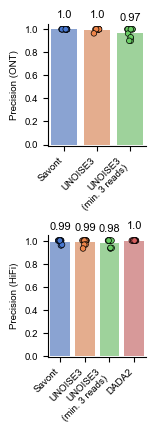

In [27]:
fig_bp, axess_bp = plt.subplots(nrows=2, ncols=1, figsize=(4/2.54, 11/2.54))
df['Number of reads'] = df['fraction']

for sample_type in ['ont', 'pb']:
    nm_upper = 10 if sample_type == 'pb' else 10_000_000
    for nm_thershold in [0]:
        if sample_type == 'ont':
            all_methods = [m for m in methods if m != 'dada2']
        else:
            all_methods = methods.copy()

        precision_summary = asv_df[asv_df['sample_type'] == sample_type].groupby(
            ['method', 'Number of reads', 'sample']).agg({
                'NM': lambda x: ((x > nm_thershold) & (x < nm_upper)).sum(),
                'target_name': 'count'
        }).round(3)
        sensitivity_summary = df[df['sample_type'] == sample_type].groupby(
            ['method', 'Number of reads', 'sample']).agg({
                'detected': 'sum'
        }).round(3)
        sensitivity_summary['sensitivity'] = sensitivity_summary['detected'] / len(ref_names)
        precision_summary.columns = ['num_false_positives', 'total_detections']
        precision_summary['precision'] = 1 - (
            precision_summary['num_false_positives'] / precision_summary['total_detections'])
        precision_summary = precision_summary.reset_index()
        sensitivity_summary = sensitivity_summary.reset_index()

        precision_summary = precision_summary[precision_summary['Number of reads'] > 100]
        sensitivity_summary = sensitivity_summary[sensitivity_summary['Number of reads'] > 100]

        bp_index = 0 if sample_type == 'ont' else 1
        sns.barplot(data=precision_summary, x='method', y='precision', hue='method',
                    ax=axess_bp[bp_index], palette=color_map, alpha=0.7, ci=None,
                    order=all_methods)
        bp = sns.stripplot(data=precision_summary, x='method', y='precision', hue='method',
                           ax=axess_bp[bp_index], palette=color_map, jitter=True,
                           size=4, edgecolor='black', linewidth=0.5)
        sns.despine(ax=axess_bp[bp_index])
        axess_bp[bp_index].set_xlabel('')
        bp.set_xticklabels(labels=[nice_names[m] for m in all_methods],
                           rotation=45, horizontalalignment='right', fontweight='light')

        for i, method in enumerate(all_methods):
            mean_p = precision_summary[precision_summary['method'] == method]['precision'].mean()
            axess_bp[bp_index].annotate(
                f'{mean_p:.2}', xy=(i, mean_p), xytext=(0, 7),
                textcoords='offset points', ha='center', va='bottom', fontsize=8)

        sample_name = 'HiFi' if sample_type == 'pb' else 'ONT'
        axess_bp[bp_index].set_ylabel(f'Precision ({sample_name})')
        axess_bp[bp_index].set_ylim(-0.01, 1.05)

plt.tight_layout()
plt.savefig(f'figures/{samples[0]}_precision_boxplot.svg', dpi=300, bbox_inches='tight')
plt.show()

## Benchmarking: Runtime and Peak RAM vs. Number of Reads

Loaded benchmark data with 105 rows
     method         sample platform       fraction  runtime_s  max_rss_gb
0    savont    v1v8_zmock1      ont  111827.811609    47.9321    2.649785
1    savont    v1v8_zmock1      ont    1318.191168     1.3970    0.215645
2    savont    v1v8_zmock1      ont   15538.424038     7.7786    0.582607
3    savont    v1v8_zmock1      ont  183162.068898    79.7780    4.228311
4    savont    v1v8_zmock1      ont    2159.057019     2.0270    0.346230
..      ...            ...      ...            ...        ...         ...
100   dada2  ziels_pb_zymo       pb   50000.000000    54.5331    1.879443
101   dada2  ziels_pb_zymo       pb     589.384300    23.1077    0.711270
102   dada2  ziels_pb_zymo       pb    6947.477500    28.3762    0.642188
103   dada2  ziels_pb_zymo       pb      81.894700    20.6909    0.858730
104   dada2  ziels_pb_zymo       pb     965.348900    21.5921    0.889316

[105 rows x 6 columns]


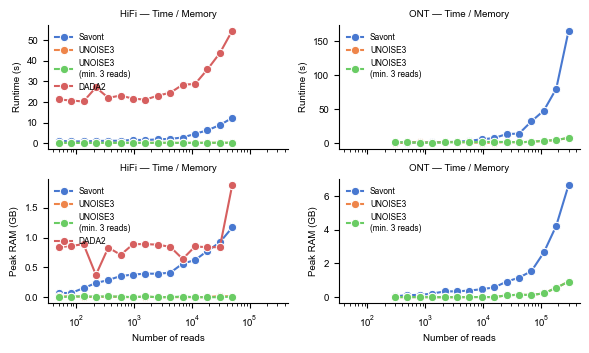

In [28]:
# ── Benchmarking: Runtime and Peak RAM vs. Number of Reads ──────────────────
fraction = False
benchmark_dir = Path('results/benchmarks')
rule_to_method = {
    'savont':              'savont',
    'unoise_denoise':      'unoise',
    'unoise_denoise_min3': 'unoise_min3',
    'dada2_denoise':       'dada2',
}

# Load unoise_uniques benchmarks keyed by (sample, fraction) — shared
# preprocessing step that must be added to both unoise and unoise_min3
uniques_dir = benchmark_dir / 'unoise_uniques'
uniques_bench = {}
if uniques_dir.exists():
    for tsv_file in sorted(uniques_dir.glob('*.tsv')):
        m = re.match(r'^(.+)_frac(\d+\.?\d*)$', tsv_file.stem)
        if not m:
            continue
        key = (m.group(1), float(m.group(2)))
        df_u = pd.read_csv(tsv_file, sep='\t')
        uniques_bench[key] = {
            'runtime_s':  df_u['s'].iloc[0],
            'max_rss_gb': df_u['max_rss'].iloc[0] / 1024,
        }
else:
    print("Warning: unoise_uniques benchmark directory not found")

bench_rows = []
for rule_name, method in rule_to_method.items():
    rule_dir = benchmark_dir / rule_name
    if not rule_dir.exists():
        print(f"Skipping {rule_dir} (not found)")
        continue
    for tsv_file in sorted(rule_dir.glob('*.tsv')):
        m = re.match(r'^(.+)_frac(\d+\.?\d*)$', tsv_file.stem)
        if not m:
            continue
        sample, frac = m.group(1), float(m.group(2))
        if sample not in sample_meta or frac not in sample_meta[sample]['fractions']:
            continue
        df_b = pd.read_csv(tsv_file, sep='\t').fillna(0)
        runtime_s  = df_b['s'].iloc[0]
        max_rss_gb = df_b['max_rss'].iloc[0] / 1024

        if method in ('unoise', 'unoise_min3'):
            u = uniques_bench.get((sample, frac), {})
            runtime_s  += u.get('runtime_s', 0)
            max_rss_gb  = max(max_rss_gb, u.get('max_rss_gb', 0))

        bench_rows.append({
            'method':      method,
            'sample':      sample,
            'platform':    sample_meta[sample]['platform'],
            'fraction':    frac,
            'runtime_s':   runtime_s,
            'max_rss_gb':  max_rss_gb,
        })

bench_df = pd.DataFrame(bench_rows)
print(f"Loaded benchmark data with {len(bench_df)} rows")
print(bench_df)

bench_df['num_reads'] = bench_df['fraction']  # fractions are absolute read counts

fig, (axes_time, axes_ram) = plt.subplots(2, 2, figsize=(15/2.54, 9/2.54),
                                           sharex=True, sharey=False)
for sample_type, (ax_time, ax_ram) in [('pb', (axes_time[0], axes_ram[0])),
                                         ('ont', (axes_time[1], axes_ram[1]))]:
    sub_samp = bench_df[bench_df['platform'] == sample_type]
    if sub_samp.empty:
        print(f"No benchmark data for platform '{sample_type}'")
        continue
    for method in rule_to_method.values():
        sub = sub_samp[sub_samp['method'] == method].sort_values('num_reads')
        if sub.empty:
            continue
        sns.lineplot(data=sub, x='fraction', y='runtime_s', ax=ax_time,
                     label=nice_names[method], color=color_map[method], marker='o')
        sns.lineplot(data=sub, x='fraction', y='max_rss_gb', ax=ax_ram,
                     label=nice_names[method], color=color_map[method], marker='o')
    for ax, ylabel in [(ax_time, 'Runtime (s)'), (ax_ram, 'Peak RAM (GB)')]:
        ax.set_xlabel('Number of reads')
        ax.set_ylabel(ylabel)
        ax.set_xscale('log')
        ax.set_title(f'{"HiFi" if sample_type == "pb" else "ONT"} — Time / Memory',
                     fontsize=7)
        ax.legend(frameon=False, fontsize=6)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f'figures/{samples[0]}_benchmark_runtime_ram.svg', dpi=300, bbox_inches='tight')
plt.show()

bench_df.to_csv('figures/timing_results.tsv', sep='\t', index=False)